In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=8,3
sns.set_theme(style="whitegrid", palette="colorblind")

In [2]:
loan = pd.read_csv(r'C:\Users\admin\Downloads\Loan Prediction.csv')

In [3]:
loan

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [4]:
loan.shape

(614, 13)

In [5]:
loan.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
loan['Gender'].fillna(loan['Gender'].mode()[0], inplace=True)
loan['Married'].fillna(loan['Married'].mode()[0], inplace=True)
loan['Dependents'].fillna(loan['Dependents'].mode()[0], inplace=True)
loan['Self_Employed'].fillna(loan['Self_Employed'].mode()[0], inplace=True)
loan['LoanAmount'].fillna(loan['LoanAmount'].median(), inplace=True)
loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].mode()[0], inplace=True)
loan['Credit_History'].fillna(loan['Credit_History'].mode()[0], inplace=True)

In [8]:
loan.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
loan.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [10]:
len(loan.columns)

13

In [11]:
loan.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [12]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [13]:
loan.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.50,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.00,1188.5,2297.25,41667.0
LoanAmount,614.0,145.752443,84.107233,9.0,100.25,128.0,164.75,700.0
Loan_Amount_Term,614.0,342.410423,64.428629,12.0,360.00,360.0,360.00,480.0
Credit_History,614.0,0.855049,0.352339,0.0,1.00,1.0,1.00,1.0


In [14]:
loan['Dependents']=loan['Dependents'].str.replace(r'\W','',regex=True) # \W--it removes the non word charachter and that  place it add Domain

In [15]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Dependents', ylabel='Density'>

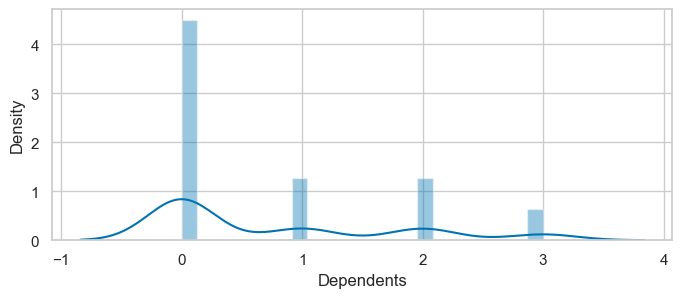

In [16]:
sns.distplot(loan.Dependents,color='b',bins=23)

<Axes: xlabel='ApplicantIncome', ylabel='Density'>

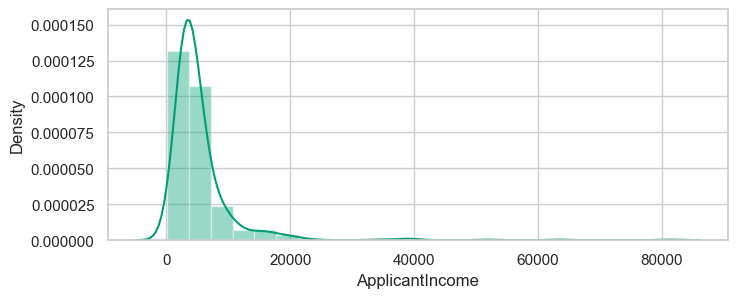

In [17]:
sns.distplot(loan.ApplicantIncome,color='g',bins=23)

<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

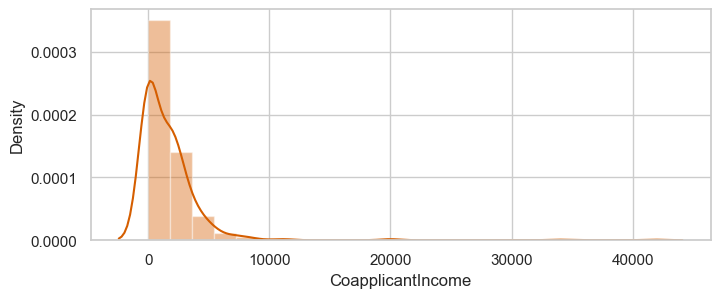

In [18]:
sns.distplot(loan.CoapplicantIncome,color='r',bins=23)

<Axes: xlabel='LoanAmount', ylabel='Density'>

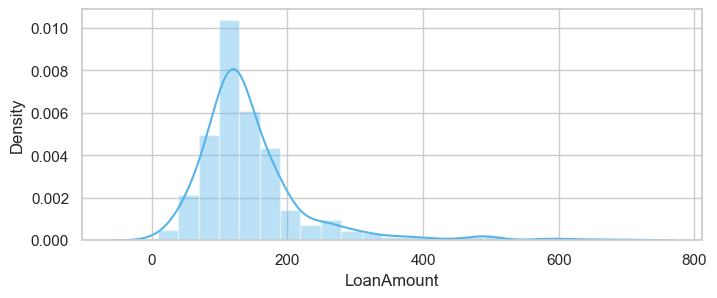

In [19]:
sns.distplot(loan.LoanAmount,color='c',bins=23)

<Axes: xlabel='Loan_Amount_Term', ylabel='Density'>

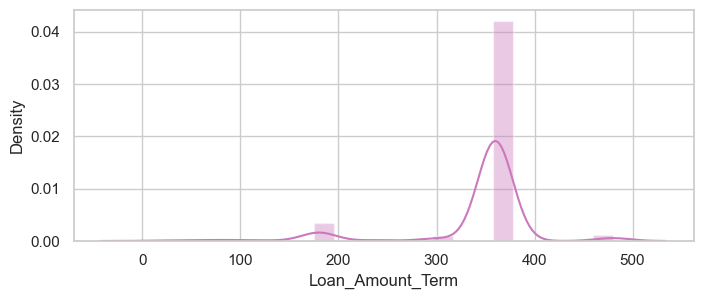

In [20]:
sns.distplot(loan.Loan_Amount_Term,color='m',bins=23)

<Axes: xlabel='Credit_History', ylabel='Density'>

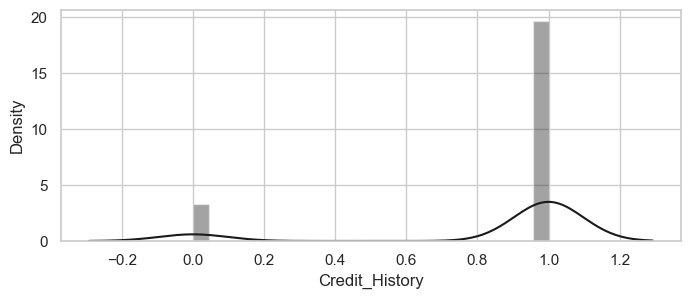

In [21]:
sns.distplot(loan.Credit_History,color='k',bins=23)

In [22]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Gender', ylabel='count'>

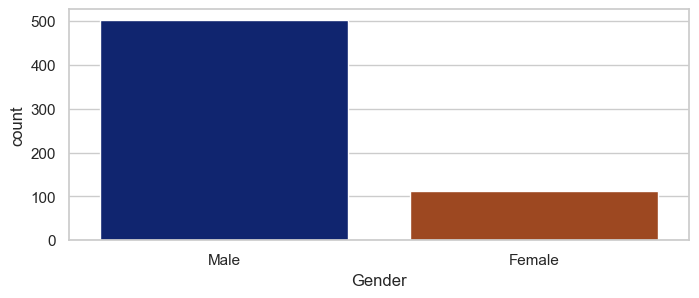

In [23]:
sns.countplot(data=loan,x='Gender',palette='dark')

<Axes: xlabel='Property_Area', ylabel='count'>

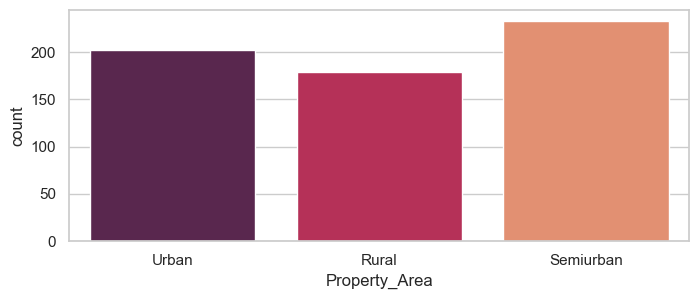

In [24]:
sns.countplot(data=loan,x='Property_Area',palette='rocket')

<Axes: xlabel='Married', ylabel='count'>

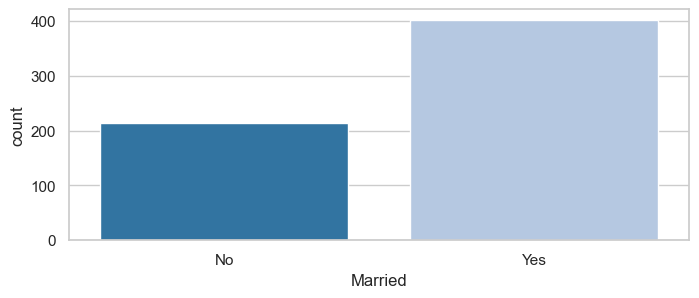

In [25]:
sns.countplot(data=loan,x='Married',palette='tab20')

<Axes: xlabel='Dependents', ylabel='count'>

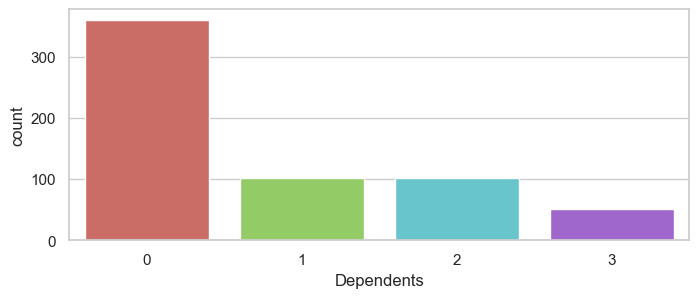

In [26]:
sns.countplot(data=loan,x='Dependents',palette='hls')

<Axes: xlabel='Education', ylabel='count'>

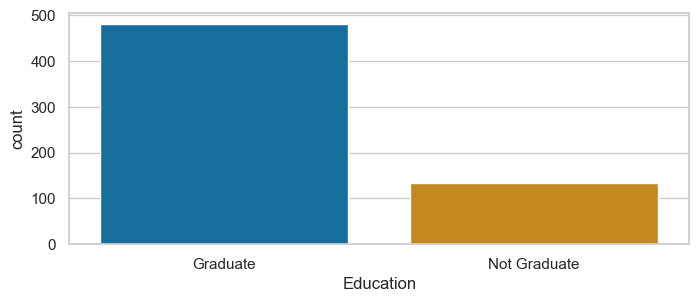

In [27]:
sns.countplot(data=loan,x='Education',palette='colorblind')

<Axes: xlabel='Self_Employed', ylabel='count'>

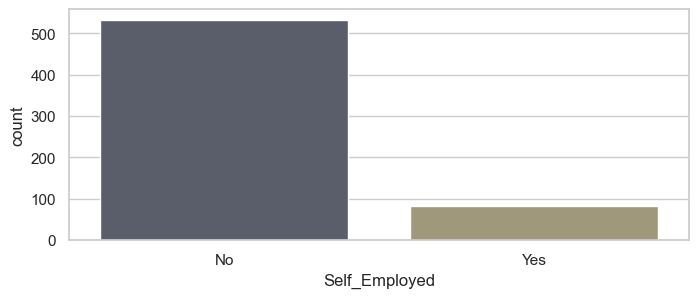

In [28]:
sns.countplot(data=loan,x='Self_Employed',palette='cividis')

<Axes: xlabel='Loan_Status', ylabel='count'>

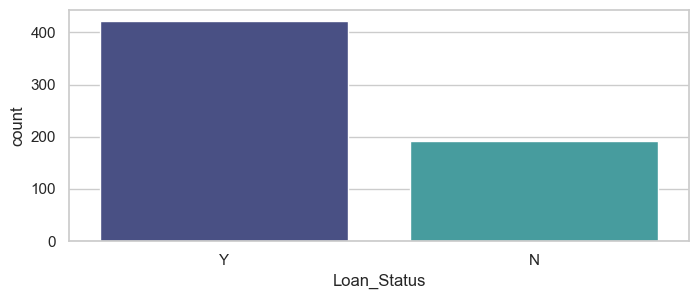

In [29]:
sns.countplot(data=loan,x='Loan_Status',palette='mako')

In [30]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Married', ylabel='count'>

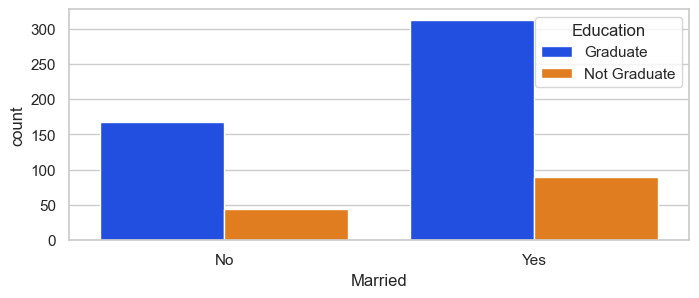

In [31]:
sns.countplot(data=loan,x='Married',hue='Education',palette='bright')

<Axes: xlabel='Gender', ylabel='count'>

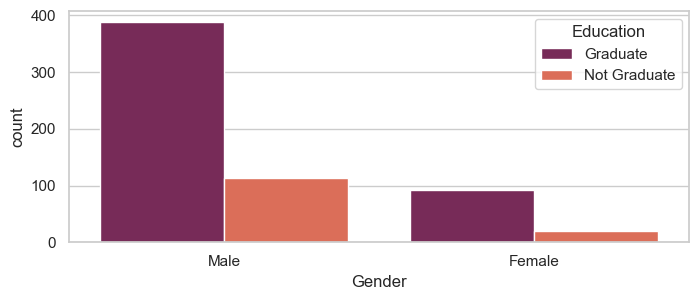

In [32]:
sns.countplot(data=loan,x='Gender',hue='Education',palette='rocket')

<Axes: xlabel='Gender', ylabel='count'>

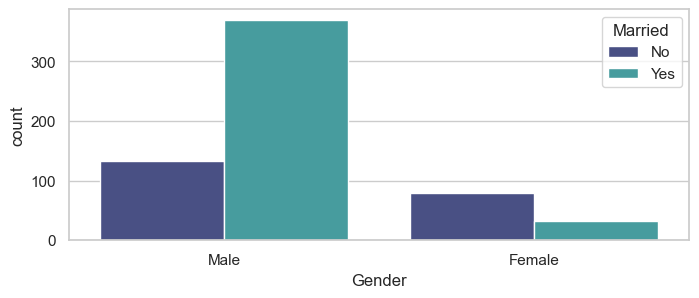

In [33]:
sns.countplot(data=loan,x='Gender',hue='Married',palette='mako')

<Axes: xlabel='Self_Employed', ylabel='count'>

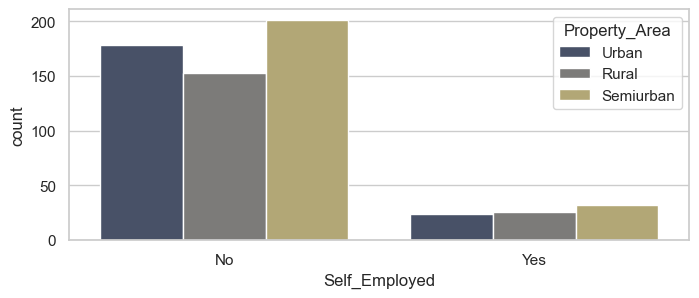

In [34]:
sns.countplot(data=loan,x='Self_Employed',hue='Property_Area',palette='cividis')

<Axes: xlabel='Education', ylabel='count'>

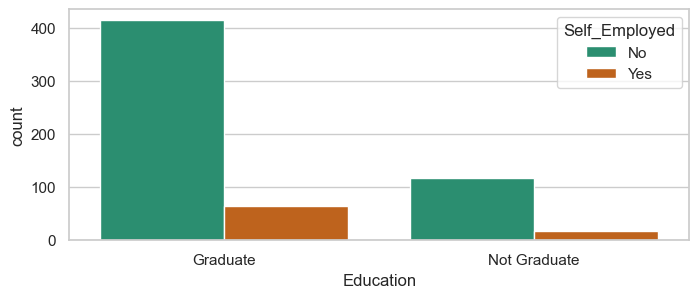

In [35]:
sns.countplot(data=loan,x='Education',hue='Self_Employed',palette='Dark2')

<Axes: xlabel='Gender', ylabel='count'>

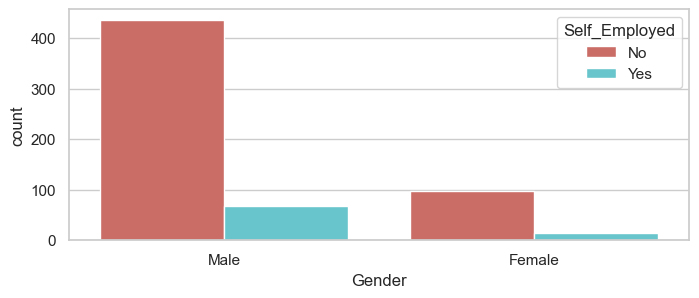

In [36]:
sns.countplot(data=loan,x='Gender',hue='Self_Employed',palette='hls')

<Axes: xlabel='Loan_Status', ylabel='count'>

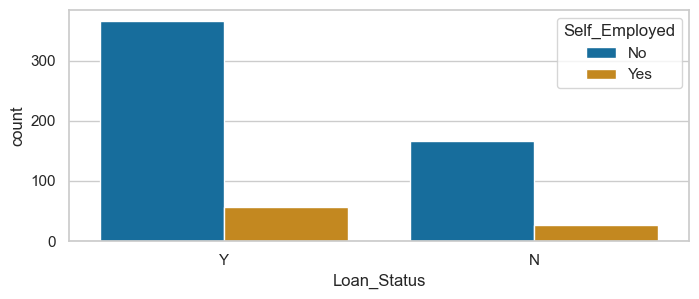

In [37]:
sns.countplot(data=loan,x='Loan_Status',hue='Self_Employed',palette='colorblind')

<Axes: xlabel='Gender', ylabel='count'>

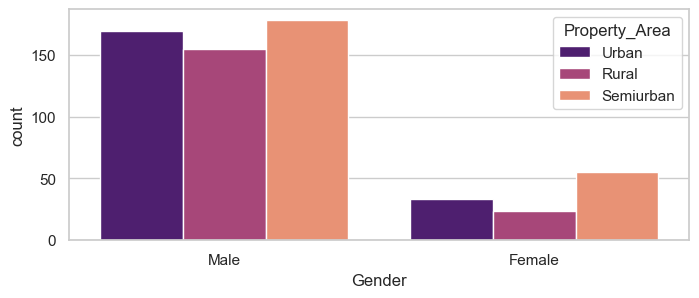

In [38]:
sns.countplot(data=loan,x='Gender',hue='Property_Area',palette='magma')

In [39]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

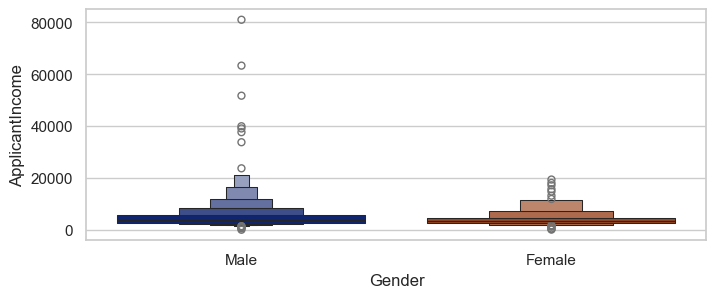

In [40]:
sns.boxenplot(data=loan,x='Gender',y='ApplicantIncome',palette='dark')

<Axes: xlabel='Married', ylabel='CoapplicantIncome'>

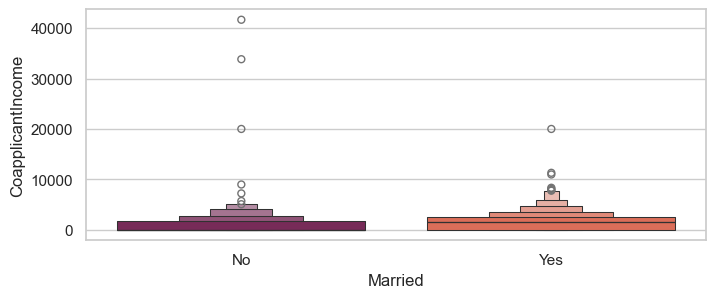

In [41]:
sns.boxenplot(data=loan,x='Married',y='CoapplicantIncome',palette='rocket')

<Axes: xlabel='Education', ylabel='LoanAmount'>

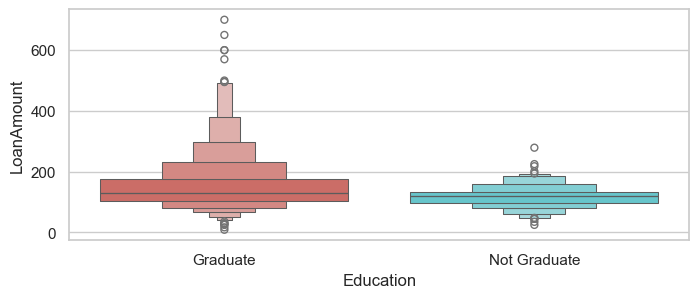

In [42]:
sns.boxenplot(data=loan,x='Education',y='LoanAmount',palette='hls')

<Axes: xlabel='Self_Employed', ylabel='Loan_Amount_Term'>

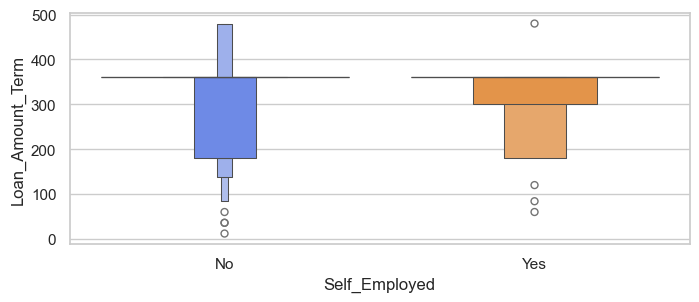

In [43]:
sns.boxenplot(data=loan,x='Self_Employed',y='Loan_Amount_Term',palette='bright')

<Axes: xlabel='Property_Area', ylabel='LoanAmount'>

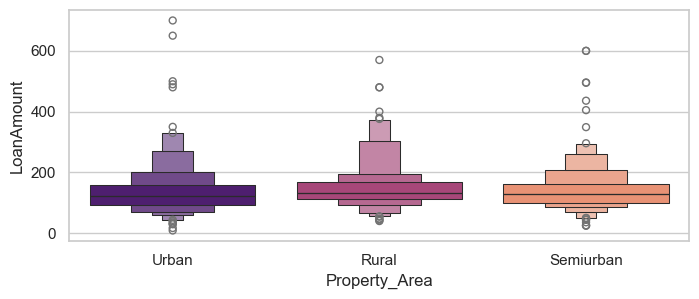

In [44]:
sns.boxenplot(data=loan,x='Property_Area',y='LoanAmount',palette='magma')

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

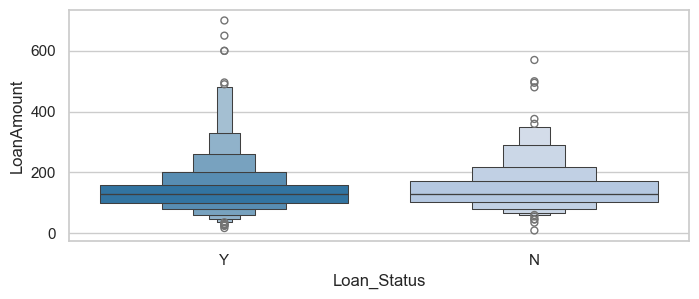

In [45]:
sns.boxenplot(data=loan,x='Loan_Status',y='LoanAmount',palette='tab20')

<Axes: xlabel='Gender', ylabel='LoanAmount'>

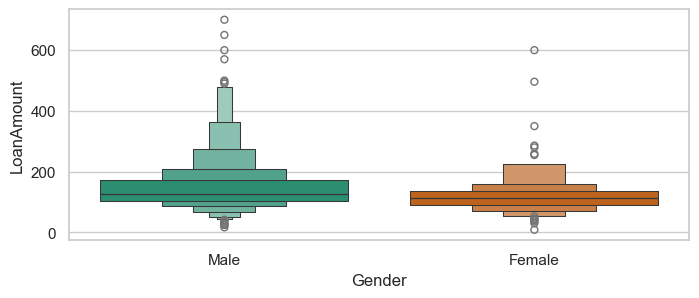

In [46]:
sns.boxenplot(data=loan,x='Gender',y='LoanAmount',palette='Dark2')

<Axes: xlabel='Education', ylabel='Loan_Amount_Term'>

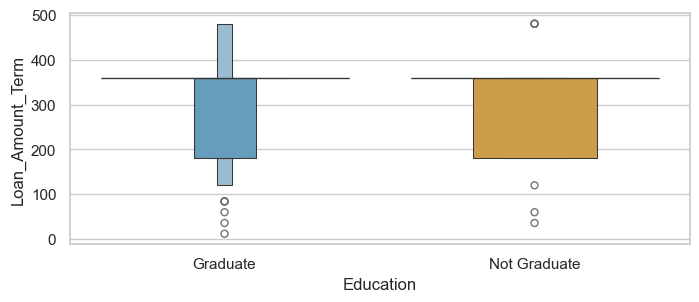

In [47]:
sns.boxenplot(data=loan,x='Education',y='Loan_Amount_Term',palette='colorblind')

In [48]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


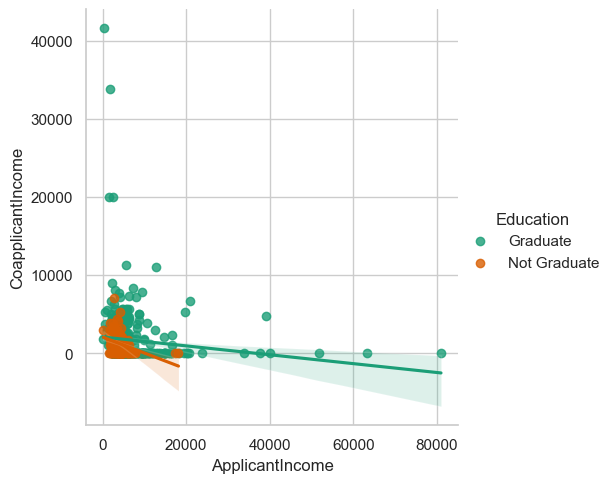

In [49]:
sns.lmplot(data=loan,x='ApplicantIncome',y='CoapplicantIncome',palette='Dark2',hue='Education')

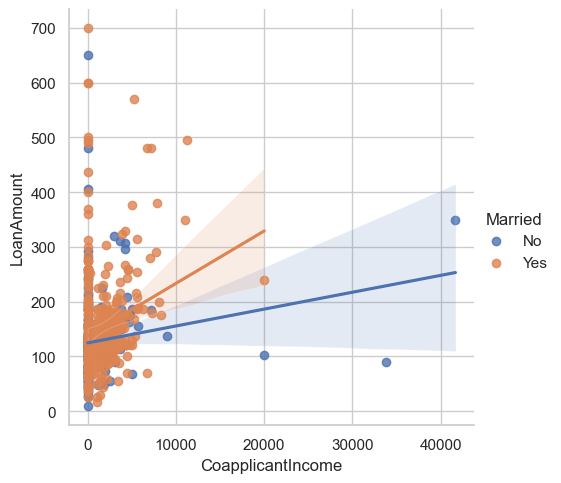

In [50]:
sns.lmplot(data=loan,x='CoapplicantIncome',y='LoanAmount',palette='deep',hue='Married')

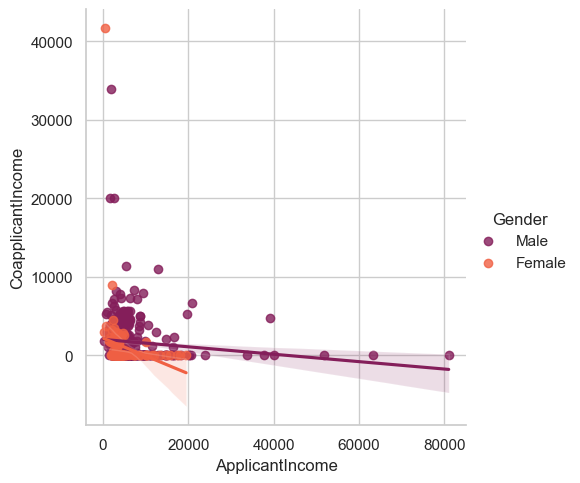

In [51]:
sns.lmplot(data=loan,x='ApplicantIncome',y='CoapplicantIncome',palette='rocket',hue='Gender')

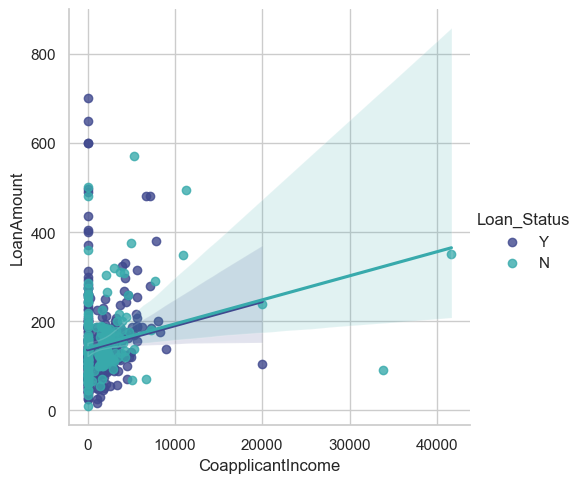

In [52]:
sns.lmplot(data=loan,x='CoapplicantIncome',y='LoanAmount',palette='mako',hue='Loan_Status')

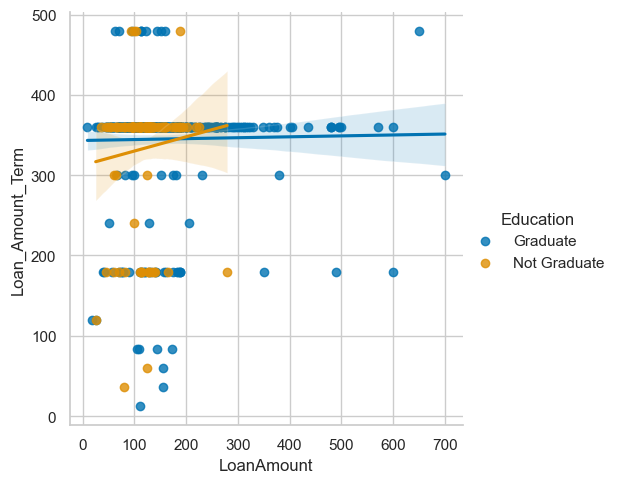

In [53]:
sns.lmplot(data=loan,x='LoanAmount',y='Loan_Amount_Term',palette='colorblind',hue='Education')

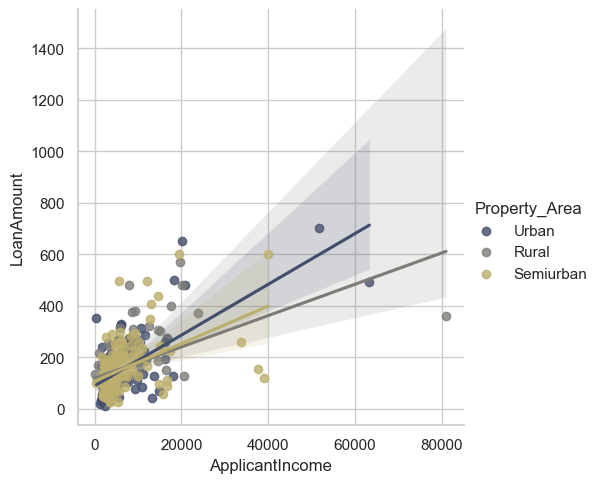

In [54]:
sns.lmplot(data=loan,x='ApplicantIncome',y='LoanAmount',palette='cividis',hue='Property_Area')

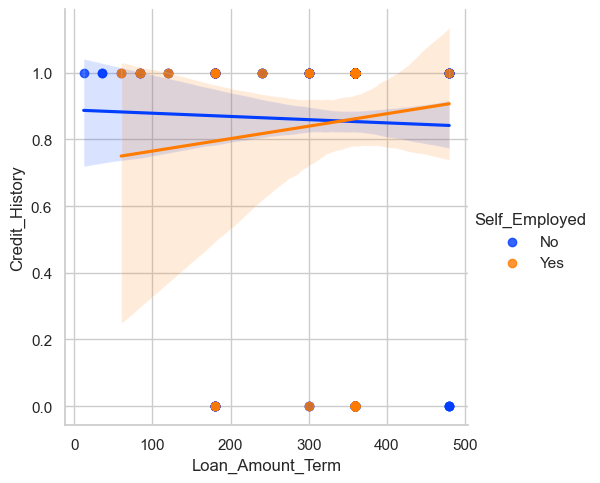

In [55]:
sns.lmplot(data=loan,x='Loan_Amount_Term',y='Credit_History',palette='bright',hue='Self_Employed')

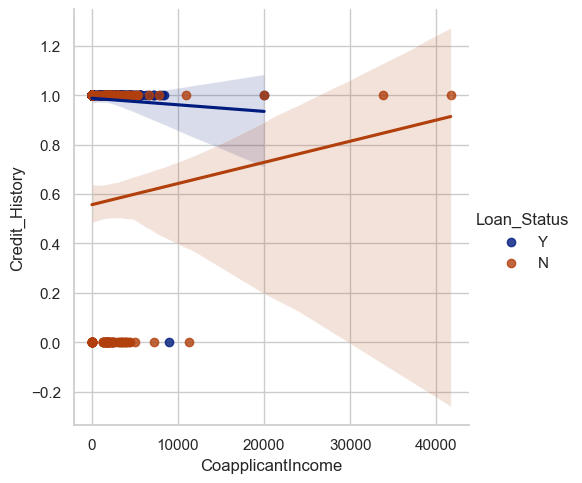

In [56]:
sns.lmplot(data=loan,x='CoapplicantIncome',y='Credit_History',palette='dark',hue='Loan_Status')

In [57]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


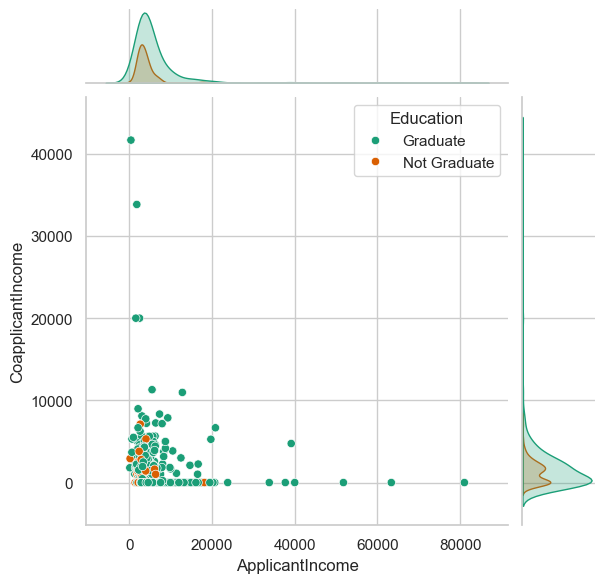

In [58]:
sns.jointplot(data=loan,x='ApplicantIncome',y='CoapplicantIncome',palette='Dark2',hue='Education')

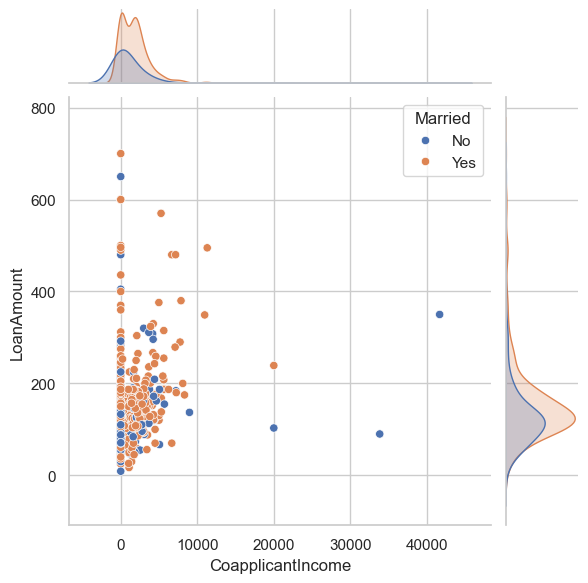

In [59]:
sns.jointplot(data=loan,x='CoapplicantIncome',y='LoanAmount',palette='deep',hue='Married')

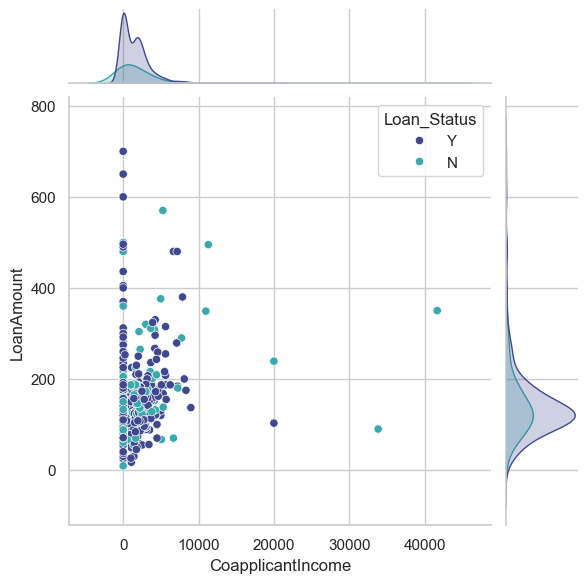

In [60]:
sns.jointplot(data=loan,x='CoapplicantIncome',y='LoanAmount',palette='mako',hue='Loan_Status')

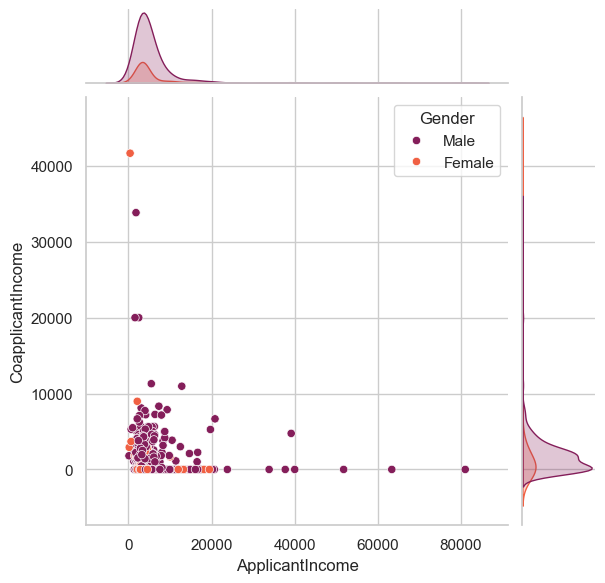

In [61]:
sns.jointplot(data=loan,x='ApplicantIncome',y='CoapplicantIncome',palette='rocket',hue='Gender')

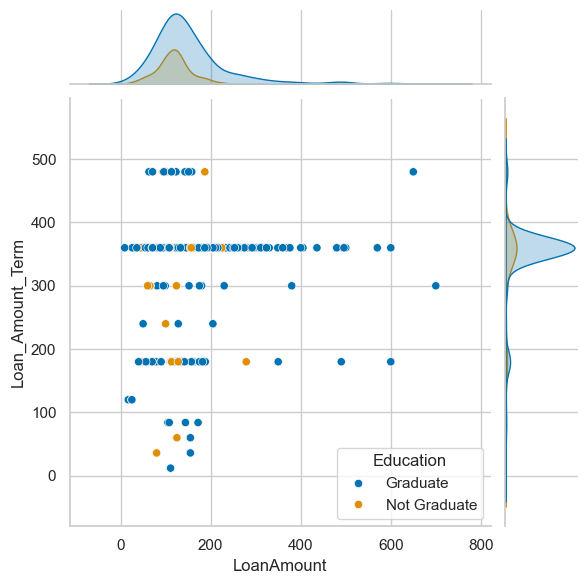

In [62]:
sns.jointplot(data=loan,x='LoanAmount',y='Loan_Amount_Term',palette='colorblind',hue='Education')

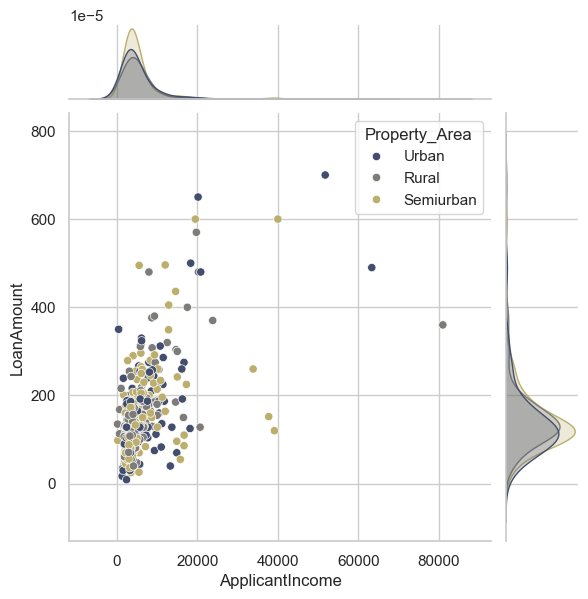

In [63]:
sns.jointplot(data=loan,x='ApplicantIncome',y='LoanAmount',palette='cividis',hue='Property_Area')

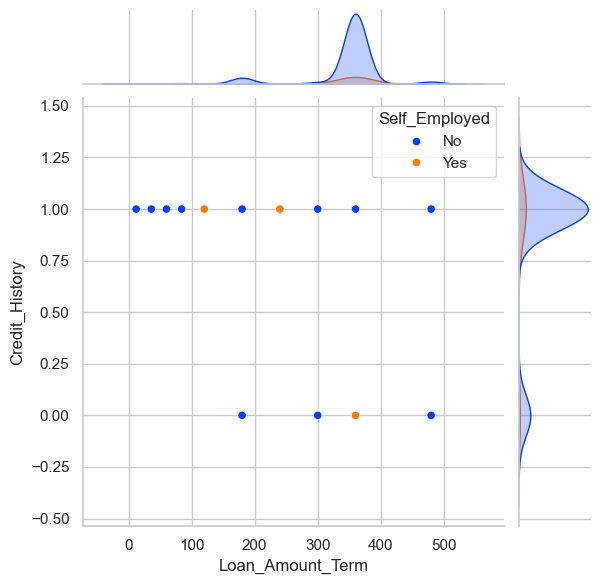

In [64]:
sns.jointplot(data=loan,x='Loan_Amount_Term',y='Credit_History',palette='bright',hue='Self_Employed')

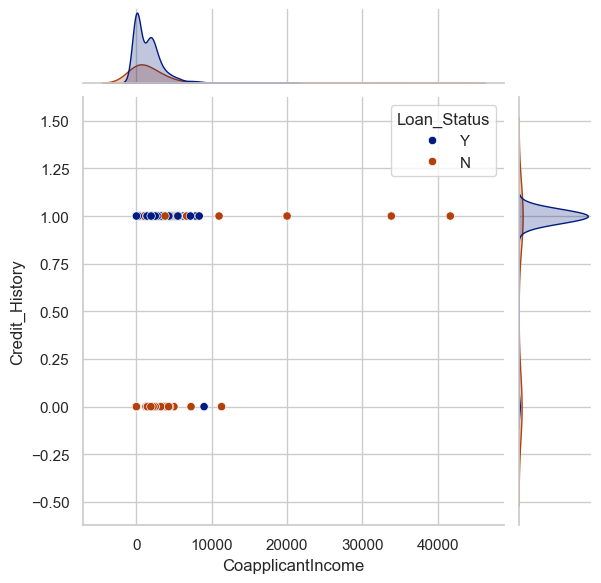

In [65]:
sns.jointplot(data=loan,x='CoapplicantIncome',y='Credit_History',palette='dark',hue='Loan_Status')

In [66]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


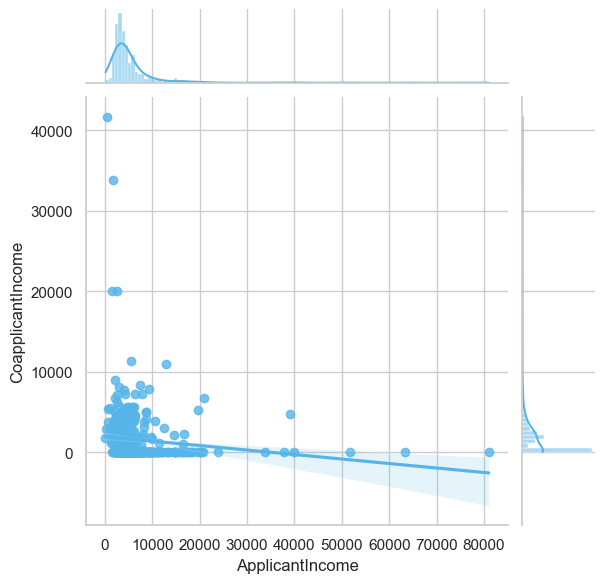

In [67]:
sns.jointplot(data=loan,x='ApplicantIncome',y='CoapplicantIncome',color='c',kind='reg')

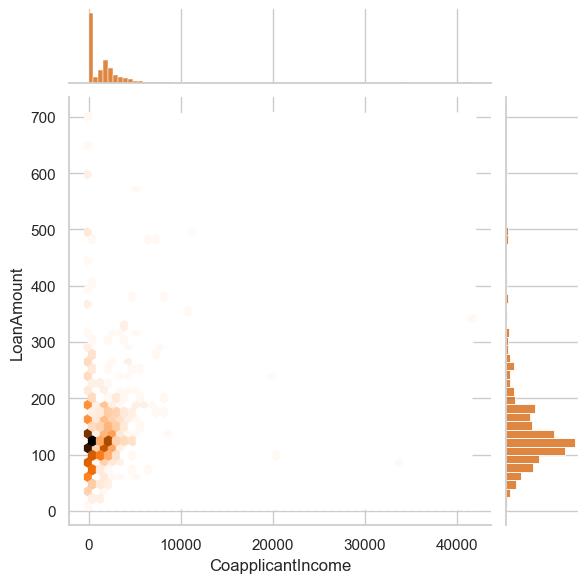

In [68]:
sns.jointplot(data=loan,x='CoapplicantIncome',y='LoanAmount',color='r',kind='hex')

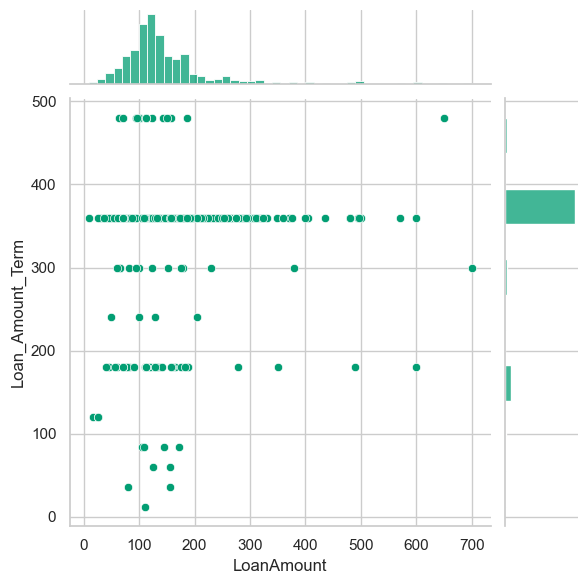

In [69]:
sns.jointplot(data=loan,x='LoanAmount',y='Loan_Amount_Term',color='g',kind='scatter')

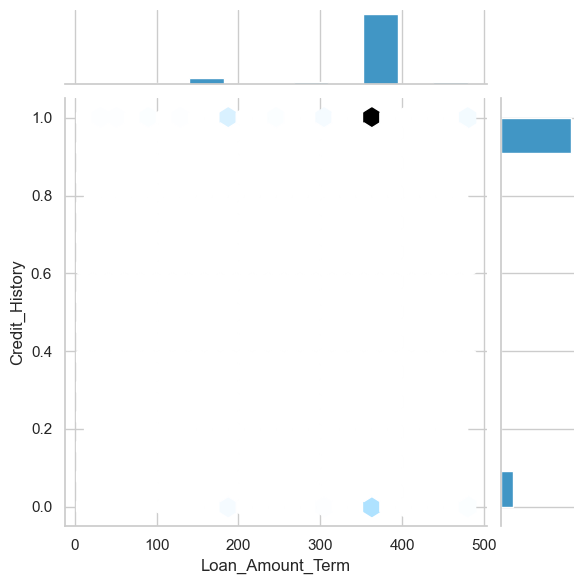

In [70]:
sns.jointplot(data=loan,x='Loan_Amount_Term',y='Credit_History',color='b',kind='hex')

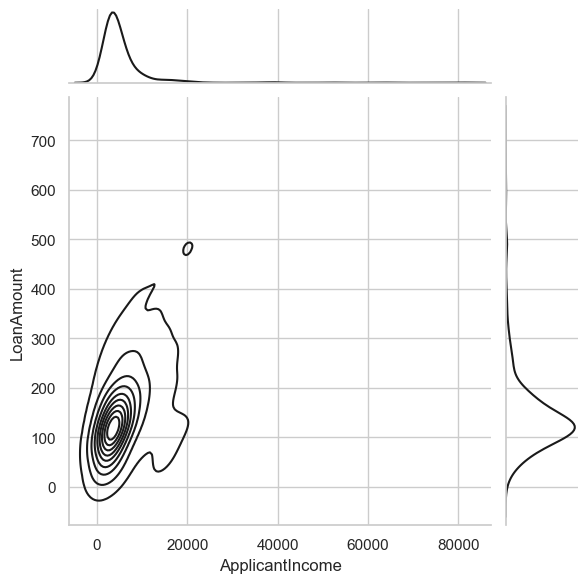

In [71]:
sns.jointplot(data=loan,x='ApplicantIncome',y='LoanAmount',color='k',kind='kde')

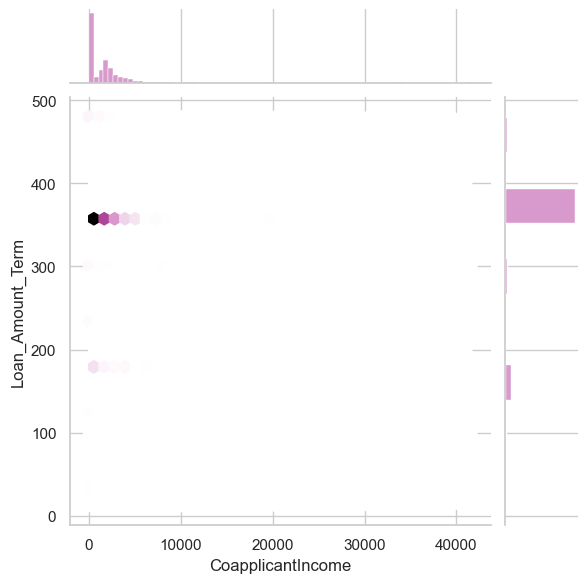

In [72]:
sns.jointplot(data=loan,x='CoapplicantIncome',y='Loan_Amount_Term',color='m',kind='hex')

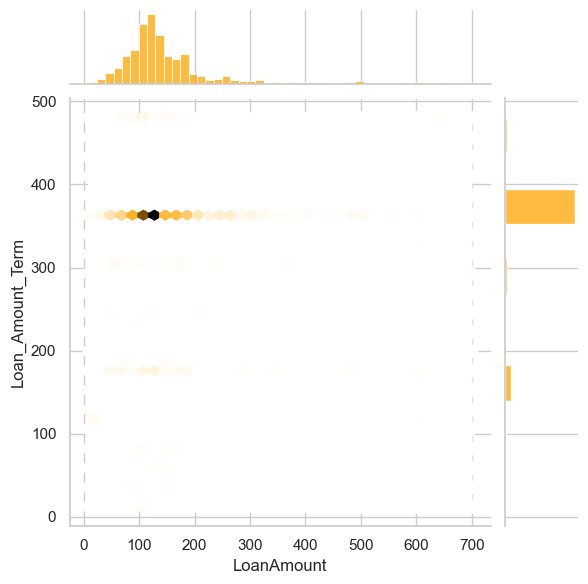

In [73]:
sns.jointplot(data=loan,x='LoanAmount',y='Loan_Amount_Term',color='orange',kind='hex')

In [74]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

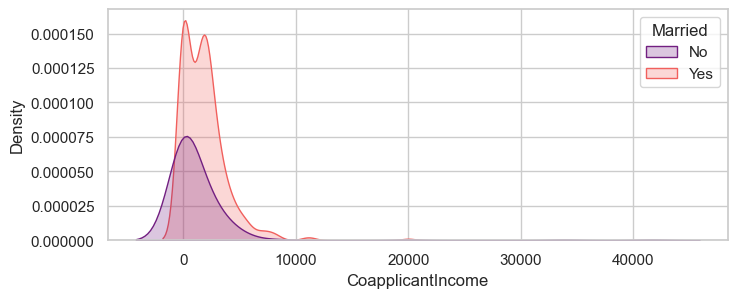

In [75]:
sns.kdeplot(data=loan,x='CoapplicantIncome',hue='Married',palette='magma',fill=True)

<Axes: xlabel='ApplicantIncome', ylabel='Density'>

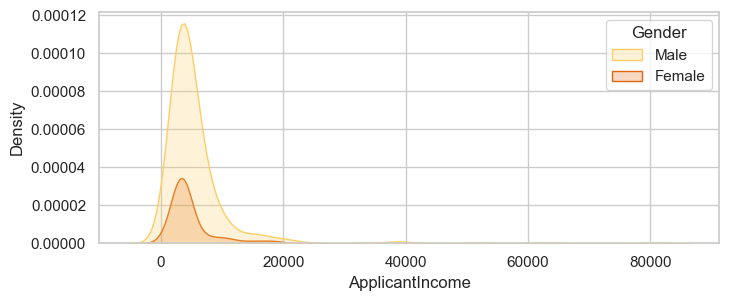

In [76]:
sns.kdeplot(data=loan,x='ApplicantIncome',hue='Gender',palette='YlOrBr',fill=True)

<Axes: xlabel='Credit_History', ylabel='Density'>

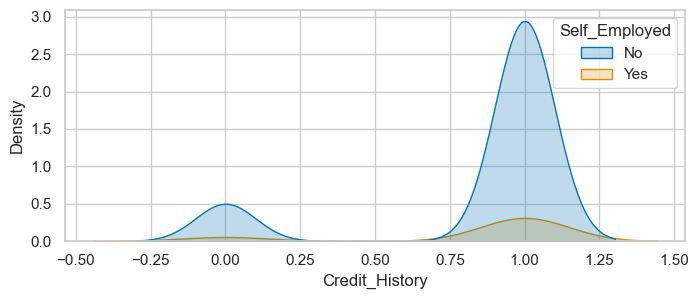

In [77]:
sns.kdeplot(data=loan,x='Credit_History',hue='Self_Employed',palette='colorblind',fill=True)

<Axes: xlabel='LoanAmount', ylabel='Density'>

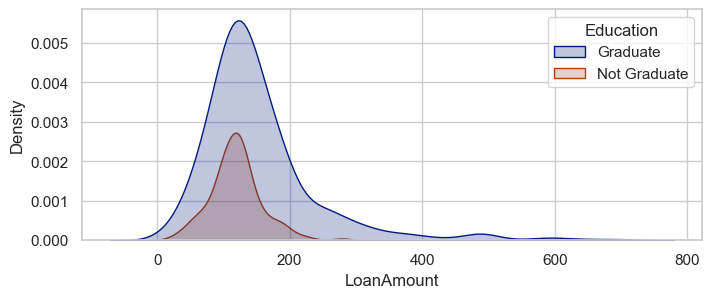

In [78]:
sns.kdeplot(data=loan,x='LoanAmount',hue='Education',palette='dark',fill=True)

<Axes: xlabel='LoanAmount', ylabel='Density'>

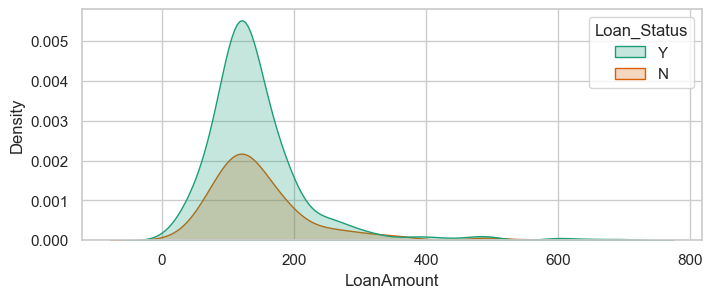

In [79]:
sns.kdeplot(data=loan,x='LoanAmount',hue='Loan_Status',palette='Dark2',fill=True)

<Axes: xlabel='Loan_Amount_Term', ylabel='Density'>

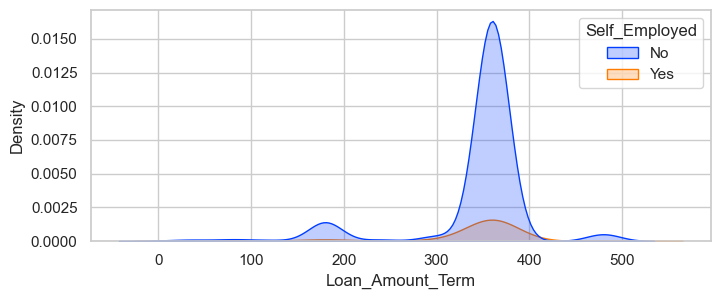

In [80]:
sns.kdeplot(data=loan,x='Loan_Amount_Term',hue='Self_Employed',palette='bright',fill=True)

In [81]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: xlabel='Married', ylabel='CoapplicantIncome'>

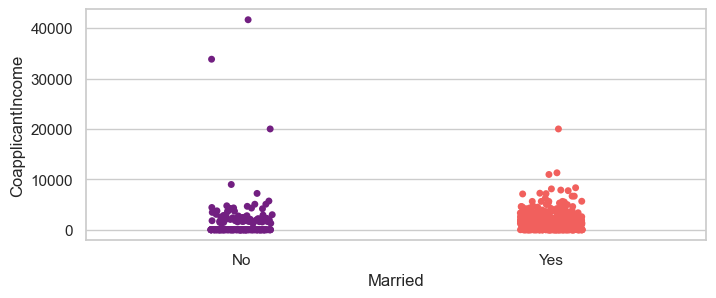

In [82]:
sns.stripplot(data=loan,y='CoapplicantIncome',x='Married',palette='magma')

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

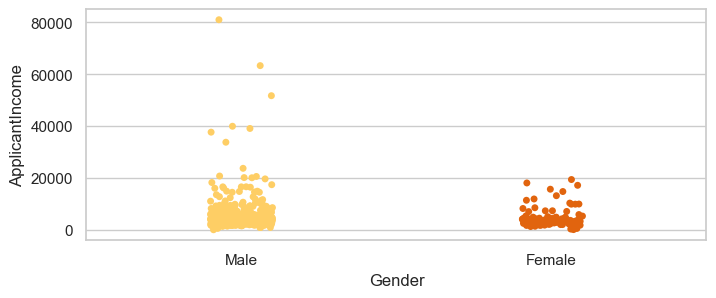

In [83]:
sns.stripplot(data=loan,y='ApplicantIncome',x='Gender',palette='YlOrBr')

<Axes: xlabel='Self_Employed', ylabel='Credit_History'>

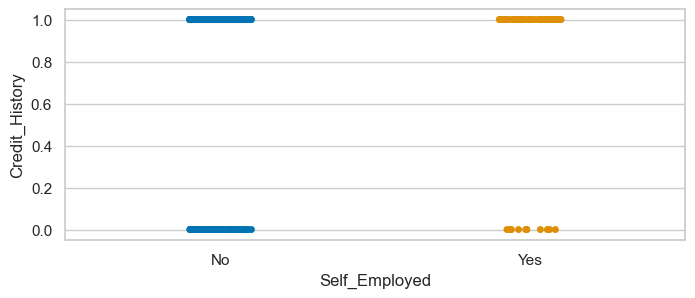

In [84]:
sns.stripplot(data=loan,y='Credit_History',x='Self_Employed',palette='colorblind')

<Axes: xlabel='Education', ylabel='LoanAmount'>

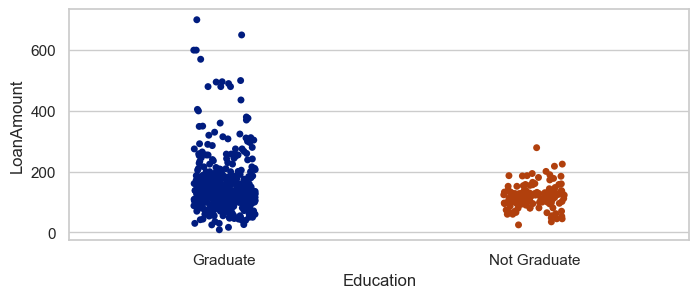

In [85]:
sns.stripplot(data=loan,y='LoanAmount',x='Education',palette='dark')

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

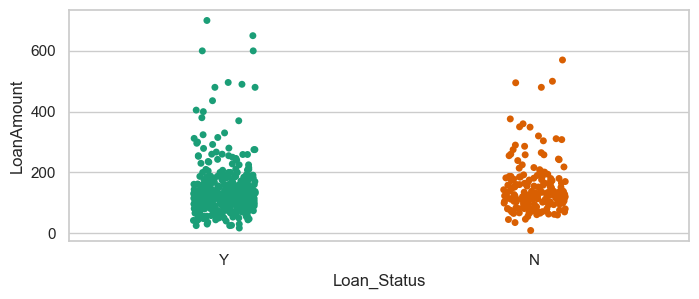

In [86]:
sns.stripplot(data=loan,y='LoanAmount',x='Loan_Status',palette='Dark2')

<Axes: xlabel='Self_Employed', ylabel='Loan_Amount_Term'>

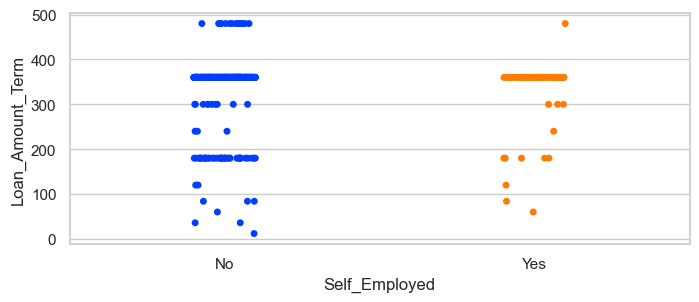

In [87]:
sns.stripplot(data=loan,y='Loan_Amount_Term',x='Self_Employed',palette='bright')